# 11. Baseline de clasificacion y experimentacion inicial

Este cuaderno implementa el bloque principal de clasificacion del proyecto sobre la capa anual final. Su objetivo es complementar la fase de regresion y evaluar con mayor detalle la capacidad de detectar eventos de perdida relevantes para la logica del seguro.

## Objetivos
- entrenar y comparar varios clasificadores sobre el target anual de evento
- mantener la misma logica de validacion temporal definida en la fase experimental
- separar la lectura de desempeno general de la lectura orientada a recall de eventos
- dejar exportaciones trazables para informe tecnico, comparacion posterior y articulacion con la capa operacional


## Enfoque de este cuaderno

La estructura general replica la disciplina metodologica usada en la fase de regresion, pero adaptada al problema categorico:

- verificacion de dependencias y carga de la base anual
- definicion de variables, feature sets y splits temporales
- smoke test del pipeline
- comparacion de varias familias de clasificadores
- ajuste de hiperparametros y de umbrales de decision
- lectura diferenciada entre desempeno general y sensibilidad a eventos
- exportacion de resultados, candidatos y observaciones metodologicas


## Dependencias y librerias esperadas

Para ejecutar todo el espacio de modelos se recomienda contar con:

- numpy
- pandas
- scikit-learn

De manera opcional, el cuaderno tambien puede aprovechar:

- xgboost
- lightgbm
- matplotlib
- seaborn

Si alguna dependencia no esta disponible, el cuaderno degrada de forma controlada y deja trazabilidad en el reporte de dependencias.


In [35]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

SKLEARN_AVAILABLE = True
try:
    from sklearn.base import clone
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.impute import SimpleImputer
    from sklearn.dummy import DummyClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
    from sklearn.neural_network import MLPClassifier
    from sklearn.metrics import roc_auc_score
except Exception:
    SKLEARN_AVAILABLE = False

XGBOOST_AVAILABLE = True
try:
    from xgboost import XGBClassifier
except Exception:
    XGBOOST_AVAILABLE = False

LIGHTGBM_AVAILABLE = True
try:
    from lightgbm import LGBMClassifier
except Exception:
    LIGHTGBM_AVAILABLE = False

MATPLOTLIB_AVAILABLE = True
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except Exception:
    MATPLOTLIB_AVAILABLE = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 240)
pd.set_option('display.max_colwidth', 180)


def find_project_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        if (candidate / 'BASE_DE_DATOS').exists():
            return candidate
    raise FileNotFoundError('No se encontro la carpeta BASE_DE_DATOS.')


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = find_project_root(CURRENT_DIR)
BASE_DIR = PROJECT_ROOT / 'BASE_DE_DATOS' / 'FINALES'
INPUT_PATH = BASE_DIR / 'dataset_modelado_anual_limpio.csv'
OUTPUT_DIR = PROJECT_ROOT / 'MODELOS' / 'resultados_11_baseline_clasificacion'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [36]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(f'No se encontro la base anual esperada: {INPUT_PATH}')

print('Base anual localizada correctamente.')
print('Archivo principal de entrada:', INPUT_PATH.name)
print('Carpeta de resultados:', OUTPUT_DIR.name)


Base anual localizada correctamente.
Archivo principal de entrada: dataset_modelado_anual_limpio.csv
Carpeta de resultados: resultados_11_baseline_clasificacion


## Carga de la base anual final

La clasificacion se monta sobre la misma capa anual utilizada en la regresion. Esto garantiza consistencia metodologica entre magnitud continua y eventos.


In [37]:
df = pd.read_csv(INPUT_PATH, sep=';').sort_values(['departamento', 'anio']).reset_index(drop=True)

if 'es_risaralda' not in df.columns:
    df['es_risaralda'] = (
        df['departamento']
        .astype(str)
        .str.strip()
        .str.lower()
        .eq('risaralda')
        .astype(int)
    )
    print('Se creo la columna auxiliar es_risaralda a partir de departamento.')

TARGET = 'evento_perdida_anual'
SUPPORT_TARGET = 'perdida_rendimiento_anual_pct'

print('Shape base anual:', df.shape)
print('Anios cubiertos:', int(df['anio'].min()), '-', int(df['anio'].max()))
print('Departamentos:', sorted(df['departamento'].unique().tolist()))
print('Eventos positivos:', int(df[TARGET].sum()))
print('Eventos negativos:', int((df[TARGET] == 0).sum()))

target_profile = pd.DataFrame([
    {
        'target': TARGET,
        'tipo': 'binario',
        'n_total': len(df),
        'n_eventos': int(df[TARGET].sum()),
        'proporcion_eventos': float(df[TARGET].mean()),
        'soporte_continuo': SUPPORT_TARGET,
    }
])
display(target_profile)



Se creo la columna auxiliar es_risaralda a partir de departamento.
Shape base anual: (36, 81)
Anios cubiertos: 2007 - 2024
Departamentos: ['Cundinamarca', 'Risaralda']
Eventos positivos: 7
Eventos negativos: 29


,target,tipo,n_total,n_eventos,proporcion_eventos,soporte_continuo
0,evento_perdida_anual,binario,36,7,0.194444,perdida_rendimiento_anual_pct


## Parametros del experimento

Se conserva la misma logica temporal de la fase anterior y se agregan umbrales de decision para explorar distintos compromisos entre recall y precision.


In [38]:
TRAIN_END_YEAR = 2020
TEST_START_YEAR = 2021
SMALL_TRAIN_END_YEAR = 2018
SMALL_VALID_END_YEAR = 2020
CV_MIN_TRAIN_YEARS = 8
CV_VALID_WINDOW = 2
THRESHOLDS = [0.25, 0.30, 0.35, 0.40, 0.50, 0.60]

dependency_report = pd.DataFrame([
    {'dependencia': 'scikit-learn', 'disponible': SKLEARN_AVAILABLE},
    {'dependencia': 'xgboost', 'disponible': XGBOOST_AVAILABLE},
    {'dependencia': 'lightgbm', 'disponible': LIGHTGBM_AVAILABLE},
    {'dependencia': 'matplotlib', 'disponible': MATPLOTLIB_AVAILABLE},
])
display(dependency_report)


,dependencia,disponible
0,scikit-learn,True
1,xgboost,True
2,lightgbm,True
3,matplotlib,True


## Helpers de evaluacion y validacion temporal

Las funciones siguientes estructuran la validacion temporal, el calculo de metricas y la recuperacion de probabilidades o scores positivos para cada clasificador.


In [39]:
run_log = []


def log(msg: str):
    run_log.append(msg)
    print(msg)


def safe_write_text(path: Path, text: str):
    path.write_text(text, encoding='utf-8')


def dependency_status_text(dep_df: pd.DataFrame):
    out = {}
    for _, row in dep_df.iterrows():
        out[str(row['dependencia'])] = bool(row['disponible'])
    return out


def make_expanding_year_folds(train_df: pd.DataFrame, min_train_years: int, valid_window: int):
    years = sorted(train_df['anio'].unique().tolist())
    folds = []
    for cutoff_pos in range(min_train_years, len(years) - valid_window + 1):
        train_years = years[:cutoff_pos]
        valid_years = years[cutoff_pos: cutoff_pos + valid_window]
        tr_idx = train_df.index[train_df['anio'].isin(train_years)].tolist()
        va_idx = train_df.index[train_df['anio'].isin(valid_years)].tolist()
        if len(tr_idx) > 0 and len(va_idx) > 0:
            folds.append({
                'train_years': train_years,
                'valid_years': valid_years,
                'train_idx': tr_idx,
                'valid_idx': va_idx,
            })
    return folds


def sigmoid(x):
    x = np.asarray(x, dtype=float)
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))


def get_positive_scores(model, X):
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return np.asarray(proba[:, 1], dtype=float)
    if hasattr(model, 'decision_function'):
        return sigmoid(model.decision_function(X))
    pred = model.predict(X)
    return np.asarray(pred, dtype=float)


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    if len(np.unique(y_true)) < 2:
        return np.nan
    try:
        return float(roc_auc_score(y_true, y_score))
    except Exception:
        return np.nan


def classification_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    total = max(len(y_true), 1)
    accuracy = (tp + tn) / total
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    balanced_accuracy = 0.5 * (recall + specificity)
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    positive_rate_pred = float(y_pred.mean())
    roc_auc = safe_auc(y_true, y_score)

    return {
        'accuracy': float(accuracy),
        'balanced_accuracy': float(balanced_accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'f1': float(f1),
        'roc_auc': float(roc_auc) if not np.isnan(roc_auc) else np.nan,
        'positive_rate_pred': positive_rate_pred,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
    }


def choose_best_threshold(fold_payloads, thresholds):
    rows = []
    for thr in thresholds:
        metrics = [classification_metrics(y_true, y_score, threshold=thr) for y_true, y_score in fold_payloads]
        rows.append({
            'threshold': thr,
            'cv_accuracy_mean': float(np.mean([m['accuracy'] for m in metrics])),
            'cv_balanced_accuracy_mean': float(np.mean([m['balanced_accuracy'] for m in metrics])),
            'cv_precision_mean': float(np.mean([m['precision'] for m in metrics])),
            'cv_recall_mean': float(np.mean([m['recall'] for m in metrics])),
            'cv_specificity_mean': float(np.mean([m['specificity'] for m in metrics])),
            'cv_f1_mean': float(np.mean([m['f1'] for m in metrics])),
            'cv_roc_auc_mean': float(np.nanmean([m['roc_auc'] for m in metrics])) if len(metrics) > 0 else np.nan,
        })
    thr_df = pd.DataFrame(rows).sort_values(
        ['cv_recall_mean', 'cv_f1_mean', 'cv_precision_mean', 'cv_balanced_accuracy_mean', 'cv_accuracy_mean'],
        ascending=[False, False, False, False, False]
    ).reset_index(drop=True)
    return thr_df.iloc[0].to_dict(), thr_df


## Definicion de datasets experimentales

Se define un split principal y un split reducido de verificacion, de forma similar a la fase de regresion.


In [40]:
main_train = df.loc[df['anio'] <= TRAIN_END_YEAR].copy().reset_index(drop=True)
main_test = df.loc[df['anio'] >= TEST_START_YEAR].copy().reset_index(drop=True)

small_train = df.loc[df['anio'] <= SMALL_TRAIN_END_YEAR].copy().reset_index(drop=True)
small_valid = df.loc[(df['anio'] > SMALL_TRAIN_END_YEAR) & (df['anio'] <= SMALL_VALID_END_YEAR)].copy().reset_index(drop=True)
small_test = main_test.copy().reset_index(drop=True)

split_summary = pd.DataFrame([
    {
        'split': 'train_principal',
        'anios': f"{int(main_train['anio'].min())}-{int(main_train['anio'].max())}",
        'n_obs': len(main_train),
        'n_eventos': int(main_train[TARGET].sum()),
    },
    {
        'split': 'test_principal',
        'anios': f"{int(main_test['anio'].min())}-{int(main_test['anio'].max())}",
        'n_obs': len(main_test),
        'n_eventos': int(main_test[TARGET].sum()),
    },
    {
        'split': 'train_small',
        'anios': f"{int(small_train['anio'].min())}-{int(small_train['anio'].max())}",
        'n_obs': len(small_train),
        'n_eventos': int(small_train[TARGET].sum()),
    },
    {
        'split': 'valid_small',
        'anios': f"{int(small_valid['anio'].min())}-{int(small_valid['anio'].max())}",
        'n_obs': len(small_valid),
        'n_eventos': int(small_valid[TARGET].sum()),
    },
])
display(split_summary)


,split,anios,n_obs,n_eventos
0,train_principal,2007-2020,28,5
1,test_principal,2021-2024,8,2
2,train_small,2007-2018,24,5
3,valid_small,2019-2020,4,0


## Construccion de estrategias de variables

Se reutiliza el enfoque de la fase anual continua para mantener comparabilidad entre ambas formulaciones.


In [41]:
baseline_parsimonioso = [
    'es_risaralda',
    'precio_ico_usd_ton',
    'precipitation_annual_sum',
    'temp_aire_C_annual_mean',
    'def_annual_mean',
    'GDD_cafe_annual_mean',
    'NDVI_anomalia_pct_annual_mean',
    'precipitation_cosecha_sum',
    'temp_aire_C_cosecha_mean',
    'NDVI_anomalia_pct_cosecha_mean',
]

annual_core = [
    'es_risaralda',
    'precio_ico_usd_ton',
    'precipitation_annual_sum',
    'temp_aire_C_annual_mean',
    'def_annual_mean',
    'GDD_cafe_annual_mean',
    'NDVI_anomalia_pct_annual_mean',
]

harvest_core = [
    'es_risaralda',
    'precio_ico_usd_ton',
    'precipitation_cosecha_sum',
    'temp_aire_C_cosecha_mean',
    'def_cosecha_mean',
    'NDVI_anomalia_pct_cosecha_mean',
]

annual_plus_terrain = annual_core + ['elevacion_media_m', 'pendiente_media']

satellite_focus = [
    'es_risaralda',
    'precio_ico_usd_ton',
    'NDVI_annual_mean',
    'EVI_annual_mean',
    'Gpp_annual_mean',
    'Lai_500m_annual_mean',
    'NDVI_anomalia_pct_cosecha_mean',
    'EVI_anomalia_pct_cosecha_mean',
    'Gpp_anomalia_pct_cosecha_mean',
]

manual_feature_sets = {
    'baseline_parsimonioso': baseline_parsimonioso,
    'annual_core': annual_core,
    'harvest_core': harvest_core,
    'annual_plus_terrain': annual_plus_terrain,
    'satellite_focus': satellite_focus,
}

train_for_selection = main_train.copy()
candidate_cols = []
for cols in manual_feature_sets.values():
    candidate_cols.extend(cols)
candidate_cols = sorted(list(dict.fromkeys([c for c in candidate_cols if c in train_for_selection.columns])))

corr_series = train_for_selection[candidate_cols + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET).abs().sort_values(ascending=False)
corr_top8_train = corr_series.head(8).index.tolist()

diversified = []
for col in corr_series.index.tolist():
    if len(diversified) == 0:
        diversified.append(col)
        continue
    corr_ok = True
    for chosen in diversified:
        pair_corr = train_for_selection[[col, chosen]].corr(numeric_only=True).iloc[0, 1]
        if pd.notna(pair_corr) and abs(pair_corr) >= 0.80:
            corr_ok = False
            break
    if corr_ok:
        diversified.append(col)
    if len(diversified) >= 8:
        break
corr_diversified_train = diversified[:8]

seleccion_l1_train = corr_top8_train.copy()
if SKLEARN_AVAILABLE:
    try:
        work = train_for_selection.dropna(subset=candidate_cols + [TARGET]).copy()
        if len(work) > 0 and work[TARGET].nunique() == 2:
            selector = Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(
                    penalty='l1',
                    C=0.5,
                    solver='liblinear',
                    class_weight='balanced',
                    max_iter=5000,
                    random_state=42,
                )),
            ])
            selector.fit(work[candidate_cols], work[TARGET])
            coef = selector.named_steps['model'].coef_[0]
            selected = [col for col, beta in zip(candidate_cols, coef) if abs(beta) > 1e-8]
            if len(selected) >= 4:
                seleccion_l1_train = selected[:8]
    except Exception as exc:
        log(f'No fue posible construir seleccion_l1_train: {exc}')

feature_sets = {
    'baseline_parsimonioso': baseline_parsimonioso,
    'annual_core': annual_core,
    'harvest_core': harvest_core,
    'annual_plus_terrain': annual_plus_terrain,
    'satellite_focus': satellite_focus,
    'corr_top8_train': corr_top8_train,
    'corr_diversified_train': corr_diversified_train,
    'seleccion_l1_train': seleccion_l1_train,
}

for name, cols in feature_sets.items():
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise AssertionError(f'Faltan columnas en {name}: {missing}')

feature_sets_table = pd.DataFrame([
    {'feature_set': name, 'n_variables': len(cols), 'variables': ', '.join(cols)}
    for name, cols in feature_sets.items()
])
display(feature_sets_table)



,feature_set,n_variables,variables
0,baseline_parsimonioso,10,"es_risaralda, precio_ico_usd_ton, precipitation_annual_sum, temp_aire_C_annual_mean, def_annual_mean, GDD_cafe_annual_mean, NDVI_anomalia_pct_annual_mean, precipitation_cosecha..."
1,annual_core,7,"es_risaralda, precio_ico_usd_ton, precipitation_annual_sum, temp_aire_C_annual_mean, def_annual_mean, GDD_cafe_annual_mean, NDVI_anomalia_pct_annual_mean"
2,harvest_core,6,"es_risaralda, precio_ico_usd_ton, precipitation_cosecha_sum, temp_aire_C_cosecha_mean, def_cosecha_mean, NDVI_anomalia_pct_cosecha_mean"
3,annual_plus_terrain,9,"es_risaralda, precio_ico_usd_ton, precipitation_annual_sum, temp_aire_C_annual_mean, def_annual_mean, GDD_cafe_annual_mean, NDVI_anomalia_pct_annual_mean, elevacion_media_m, pe..."
4,satellite_focus,9,"es_risaralda, precio_ico_usd_ton, NDVI_annual_mean, EVI_annual_mean, Gpp_annual_mean, Lai_500m_annual_mean, NDVI_anomalia_pct_cosecha_mean, EVI_anomalia_pct_cosecha_mean, Gpp_a..."
5,corr_top8_train,8,"temp_aire_C_cosecha_mean, NDVI_anomalia_pct_cosecha_mean, def_cosecha_mean, temp_aire_C_annual_mean, EVI_anomalia_pct_cosecha_mean, precipitation_cosecha_sum, EVI_annual_mean, ..."
6,corr_diversified_train,8,"temp_aire_C_cosecha_mean, NDVI_anomalia_pct_cosecha_mean, def_cosecha_mean, precipitation_cosecha_sum, EVI_annual_mean, NDVI_annual_mean, precio_ico_usd_ton, def_annual_mean"
7,seleccion_l1_train,8,"temp_aire_C_cosecha_mean, NDVI_anomalia_pct_cosecha_mean, def_cosecha_mean, temp_aire_C_annual_mean, EVI_anomalia_pct_cosecha_mean, precipitation_cosecha_sum, EVI_annual_mean, ..."


## Smoke test del pipeline de clasificacion

Antes de lanzar todo el espacio de clasificadores se verifica que el flujo general funcione en una configuracion pequena.


In [42]:
smoke_test_result = None

if SKLEARN_AVAILABLE and len(small_train) > 0 and len(small_valid) > 0:
    smoke_features = feature_sets['baseline_parsimonioso']
    smoke_train = small_train.dropna(subset=smoke_features + [TARGET]).copy()
    smoke_valid = small_valid.dropna(subset=smoke_features + [TARGET]).copy()
    if len(smoke_train) > 0 and len(smoke_valid) > 0 and smoke_train[TARGET].nunique() == 2:
        smoke_model = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)),
        ])
        smoke_model.fit(smoke_train[smoke_features], smoke_train[TARGET])
        smoke_score = get_positive_scores(smoke_model, smoke_valid[smoke_features])
        smoke_metrics = classification_metrics(smoke_valid[TARGET], smoke_score, threshold=0.5)
        smoke_test_result = pd.DataFrame([{
            'modelo': 'LogisticRegression_smoke',
            'feature_set': 'baseline_parsimonioso',
            'n_train': len(smoke_train),
            'n_valid': len(smoke_valid),
            'accuracy': smoke_metrics['accuracy'],
            'balanced_accuracy': smoke_metrics['balanced_accuracy'],
            'precision': smoke_metrics['precision'],
            'recall': smoke_metrics['recall'],
            'f1': smoke_metrics['f1'],
        }])
        display(smoke_test_result)
    else:
        print('No fue posible correr smoke test por falta de clases en entrenamiento o por filas insuficientes.')
else:
    print('Smoke test omitido porque faltan dependencias de clasificacion.')



,modelo,feature_set,n_train,n_valid,accuracy,balanced_accuracy,precision,recall,f1
0,LogisticRegression_smoke,baseline_parsimonioso,24,4,0.75,0.375,0.0,0.0,0.0


## Registro de clasificadores a comparar

Se incluyen familias lineales, arboles, boosting, redes neuronales y baselines simples. La intencion es contrastar interpretabilidad, flexibilidad, estabilidad temporal y capacidad para capturar eventos.


In [43]:
model_specs = [
    {
        'model_name': 'DummyClassifier_prior',
        'family': 'baseline_simple',
        'param_grid': [{}],
    },
    {
        'model_name': 'LogisticRegression_l2',
        'family': 'lineal',
        'param_grid': [
            {'C': 0.2},
            {'C': 1.0},
            {'C': 5.0},
        ],
    },
    {
        'model_name': 'LogisticRegression_l1',
        'family': 'lineal_regularizado',
        'param_grid': [
            {'C': 0.2},
            {'C': 1.0},
            {'C': 5.0},
        ],
    },
    {
        'model_name': 'LogisticRegression_elasticnet',
        'family': 'lineal_regularizado',
        'param_grid': [
            {'C': 0.5, 'l1_ratio': 0.2},
            {'C': 1.0, 'l1_ratio': 0.5},
            {'C': 1.0, 'l1_ratio': 0.8},
        ],
    },
    {
        'model_name': 'RandomForestClassifier',
        'family': 'arboles',
        'param_grid': [
            {'n_estimators': 400, 'max_depth': 3, 'min_samples_leaf': 1},
            {'n_estimators': 800, 'max_depth': 4, 'min_samples_leaf': 2},
        ],
    },
    {
        'model_name': 'ExtraTreesClassifier',
        'family': 'arboles',
        'param_grid': [
            {'n_estimators': 400, 'max_depth': 3, 'min_samples_leaf': 1},
            {'n_estimators': 800, 'max_depth': 4, 'min_samples_leaf': 2},
        ],
    },
    {
        'model_name': 'GradientBoostingClassifier',
        'family': 'boosting',
        'param_grid': [
            {'n_estimators': 150, 'learning_rate': 0.03, 'max_depth': 2, 'min_samples_leaf': 1},
            {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 1},
        ],
    },
    {
        'model_name': 'HistGradientBoostingClassifier',
        'family': 'boosting',
        'param_grid': [
            {'learning_rate': 0.03, 'max_depth': 3, 'max_iter': 200, 'min_samples_leaf': 2},
            {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 300, 'min_samples_leaf': 2},
        ],
    },
    {
        'model_name': 'MLPClassifier_shallow',
        'family': 'red_neuronal',
        'param_grid': [
            {'hidden_layer_sizes': (12,), 'alpha': 0.001, 'learning_rate_init': 0.001},
            {'hidden_layer_sizes': (16,), 'alpha': 0.005, 'learning_rate_init': 0.001},
        ],
    },
]

if XGBOOST_AVAILABLE:
    model_specs.append({
        'model_name': 'XGBoostClassifier',
        'family': 'boosting',
        'param_grid': [
            {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 1.0},
            {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 1.0},
        ],
    })

if LIGHTGBM_AVAILABLE:
    model_specs.append({
        'model_name': 'LightGBMClassifier',
        'family': 'boosting',
        'param_grid': [
            {'n_estimators': 200, 'num_leaves': 15, 'learning_rate': 0.03, 'min_child_samples': 2, 'subsample': 0.8, 'colsample_bytree': 1.0},
            {'n_estimators': 300, 'num_leaves': 31, 'learning_rate': 0.05, 'min_child_samples': 2, 'subsample': 0.8, 'colsample_bytree': 1.0},
        ],
    })

model_registry = pd.DataFrame([
    {'model_name': spec['model_name'], 'family': spec['family'], 'n_configuraciones': len(spec['param_grid'])}
    for spec in model_specs
])
display(model_registry)


,model_name,family,n_configuraciones
0,DummyClassifier_prior,baseline_simple,1
1,LogisticRegression_l2,lineal,3
2,LogisticRegression_l1,lineal_regularizado,3
3,LogisticRegression_elasticnet,lineal_regularizado,3
4,RandomForestClassifier,arboles,2
5,ExtraTreesClassifier,arboles,2
6,GradientBoostingClassifier,boosting,2
7,HistGradientBoostingClassifier,boosting,2
8,MLPClassifier_shallow,red_neuronal,2
9,XGBoostClassifier,boosting,2


## Builders de modelos

Cada clasificador se encapsula para reutilizar un protocolo comun de entrenamiento, scoring y comparacion.


In [44]:
def build_model(model_name, params):
    if not SKLEARN_AVAILABLE:
        raise RuntimeError('scikit-learn no esta disponible.')

    if model_name == 'DummyClassifier_prior':
        return DummyClassifier(strategy='prior')

    if model_name == 'LogisticRegression_l2':
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                penalty='l2',
                C=params['C'],
                solver='liblinear',
                class_weight='balanced',
                max_iter=5000,
                random_state=42,
            )),
        ])

    if model_name == 'LogisticRegression_l1':
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                penalty='l1',
                C=params['C'],
                solver='liblinear',
                class_weight='balanced',
                max_iter=5000,
                random_state=42,
            )),
        ])

    if model_name == 'LogisticRegression_elasticnet':
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                penalty='elasticnet',
                C=params['C'],
                l1_ratio=params['l1_ratio'],
                solver='saga',
                class_weight='balanced',
                max_iter=8000,
                random_state=42,
            )),
        ])

    if model_name == 'RandomForestClassifier':
        return RandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            class_weight='balanced',
            random_state=42,
            n_jobs=1,
        )

    if model_name == 'ExtraTreesClassifier':
        return ExtraTreesClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            class_weight='balanced',
            random_state=42,
            n_jobs=1,
        )

    if model_name == 'GradientBoostingClassifier':
        return GradientBoostingClassifier(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=42,
        )

    if model_name == 'HistGradientBoostingClassifier':
        return HistGradientBoostingClassifier(
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            max_iter=params['max_iter'],
            min_samples_leaf=params['min_samples_leaf'],
            early_stopping=False,
            random_state=42,
        )

    if model_name == 'MLPClassifier_shallow':
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', MLPClassifier(
                hidden_layer_sizes=params['hidden_layer_sizes'],
                alpha=params['alpha'],
                learning_rate_init=params['learning_rate_init'],
                solver='lbfgs',
                max_iter=4000,
                random_state=42,
            )),
        ])

    if model_name == 'XGBoostClassifier' and XGBOOST_AVAILABLE:
        return XGBClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_jobs=1,
            verbosity=0,
        )

    if model_name == 'LightGBMClassifier' and LIGHTGBM_AVAILABLE:
        return LGBMClassifier(
            n_estimators=params['n_estimators'],
            num_leaves=params['num_leaves'],
            learning_rate=params['learning_rate'],
            min_child_samples=params['min_child_samples'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            objective='binary',
            random_state=42,
            n_jobs=1,
            verbose=-1,
        )

    raise ValueError(f'Modelo no soportado o dependencia no disponible: {model_name}')


## Loop principal de experimentacion

Se comparan clasificadores y conjuntos de variables con validacion temporal, seleccion de hiperparametros y ajuste de umbral de decision.


In [45]:
cv_results = []
test_results = []
prediction_rows = []
best_models_cache = {}

if SKLEARN_AVAILABLE:
    for feature_set_name, features in feature_sets.items():
        work_df = df.dropna(subset=features + [TARGET]).copy().reset_index(drop=True)
        train_df = work_df.loc[work_df['anio'] <= TRAIN_END_YEAR].copy().reset_index(drop=True)
        test_df = work_df.loc[work_df['anio'] >= TEST_START_YEAR].copy().reset_index(drop=True)

        if len(train_df) == 0 or len(test_df) == 0 or train_df[TARGET].nunique() < 2:
            log(f'Se omite {feature_set_name} por falta de filas o clases en train/test.')
            continue

        cv_folds = make_expanding_year_folds(train_df, min_train_years=CV_MIN_TRAIN_YEARS, valid_window=CV_VALID_WINDOW)
        if len(cv_folds) == 0:
            log(f'Se omite {feature_set_name} porque no se pudieron construir folds temporales.')
            continue

        for spec in model_specs:
            model_name = spec['model_name']
            best_payload = None

            for params in spec['param_grid']:
                fold_payloads = []
                fold_success = True

                for fold in cv_folds:
                    tr = train_df.loc[fold['train_idx']].copy()
                    va = train_df.loc[fold['valid_idx']].copy()
                    if tr[TARGET].nunique() < 2:
                        fold_success = False
                        break
                    if va[TARGET].nunique() < 2:
                        log(f"Fold con una sola clase en validacion para {model_name} | {feature_set_name} | anios {fold['valid_years']}. Se mantiene la evaluacion sin ROC-AUC interpretable.")
                    try:
                        model = build_model(model_name, params)
                        model.fit(tr[features], tr[TARGET])
                        y_score_va = get_positive_scores(model, va[features])
                        fold_payloads.append((va[TARGET].to_numpy(), y_score_va))
                    except Exception as exc:
                        fold_success = False
                        log(f'Fallo {model_name} en {feature_set_name} con params {params}: {exc}')
                        break

                if not fold_success or len(fold_payloads) == 0:
                    continue

                thr_best, thr_df = choose_best_threshold(fold_payloads, THRESHOLDS)

                candidate = {
                    'params': params,
                    'threshold': float(thr_best['threshold']),
                    'cv_accuracy_mean': float(thr_best['cv_accuracy_mean']),
                    'cv_balanced_accuracy_mean': float(thr_best['cv_balanced_accuracy_mean']),
                    'cv_precision_mean': float(thr_best['cv_precision_mean']),
                    'cv_recall_mean': float(thr_best['cv_recall_mean']),
                    'cv_specificity_mean': float(thr_best['cv_specificity_mean']),
                    'cv_f1_mean': float(thr_best['cv_f1_mean']),
                    'cv_roc_auc_mean': float(thr_best['cv_roc_auc_mean']) if not np.isnan(thr_best['cv_roc_auc_mean']) else np.nan,
                }

                if best_payload is None:
                    best_payload = candidate
                else:
                    current_key = (
                        candidate['cv_recall_mean'],
                        candidate['cv_f1_mean'],
                        candidate['cv_precision_mean'],
                        candidate['cv_balanced_accuracy_mean'],
                        candidate['cv_accuracy_mean'],
                        candidate['cv_roc_auc_mean'] if not np.isnan(candidate['cv_roc_auc_mean']) else -999.0,
                    )
                    best_key = (
                        best_payload['cv_recall_mean'],
                        best_payload['cv_f1_mean'],
                        best_payload['cv_precision_mean'],
                        best_payload['cv_balanced_accuracy_mean'],
                        best_payload['cv_accuracy_mean'],
                        best_payload['cv_roc_auc_mean'] if not np.isnan(best_payload['cv_roc_auc_mean']) else -999.0,
                    )
                    if current_key > best_key:
                        best_payload = candidate

            if best_payload is None:
                continue

            try:
                final_model = build_model(model_name, best_payload['params'])
                final_model.fit(train_df[features], train_df[TARGET])
                y_score_test = get_positive_scores(final_model, test_df[features])
                test_metrics = classification_metrics(test_df[TARGET], y_score_test, threshold=best_payload['threshold'])

                cv_results.append({
                    'model_name': model_name,
                    'family': spec['family'],
                    'feature_set': feature_set_name,
                    'n_features': len(features),
                    'best_params': json.dumps(best_payload['params'], ensure_ascii=False, sort_keys=True),
                    'threshold_cv_optimo': float(best_payload['threshold']),
                    'cv_accuracy_mean': best_payload['cv_accuracy_mean'],
                    'cv_balanced_accuracy_mean': best_payload['cv_balanced_accuracy_mean'],
                    'cv_precision_mean': best_payload['cv_precision_mean'],
                    'cv_recall_mean': best_payload['cv_recall_mean'],
                    'cv_specificity_mean': best_payload['cv_specificity_mean'],
                    'cv_f1_mean': best_payload['cv_f1_mean'],
                    'cv_roc_auc_mean': best_payload['cv_roc_auc_mean'],
                })

                test_results.append({
                    'model_name': model_name,
                    'family': spec['family'],
                    'feature_set': feature_set_name,
                    'n_features': len(features),
                    'best_params': json.dumps(best_payload['params'], ensure_ascii=False, sort_keys=True),
                    'threshold_used': float(best_payload['threshold']),
                    'test_accuracy': test_metrics['accuracy'],
                    'test_balanced_accuracy': test_metrics['balanced_accuracy'],
                    'test_precision': test_metrics['precision'],
                    'test_recall': test_metrics['recall'],
                    'test_specificity': test_metrics['specificity'],
                    'test_f1': test_metrics['f1'],
                    'test_roc_auc': test_metrics['roc_auc'],
                    'test_positive_rate_pred': test_metrics['positive_rate_pred'],
                    'tp': test_metrics['tp'],
                    'fp': test_metrics['fp'],
                    'fn': test_metrics['fn'],
                    'tn': test_metrics['tn'],
                    'train_positive_share': float(train_df[TARGET].mean()),
                    'test_positive_share': float(test_df[TARGET].mean()),
                })

                best_models_cache[(model_name, feature_set_name)] = {
                    'model': final_model,
                    'threshold': float(best_payload['threshold']),
                    'features': features,
                    'test_df': test_df.copy(),
                    'test_scores': y_score_test.copy(),
                }

                for row_idx, row in test_df.reset_index(drop=True).iterrows():
                    prediction_rows.append({
                        'model_name': model_name,
                        'family': spec['family'],
                        'feature_set': feature_set_name,
                        'threshold_used': float(best_payload['threshold']),
                        'departamento': row['departamento'],
                        'anio': int(row['anio']),
                        'y_true': int(row[TARGET]),
                        'y_score': float(y_score_test[row_idx]),
                        'y_pred': int(y_score_test[row_idx] >= best_payload['threshold']),
                    })
            except Exception as exc:
                log(f'Fallo en ajuste final de {model_name} con {feature_set_name}: {exc}')
else:
    print('No hay dependencias suficientes para ejecutar clasificadores en este entorno.')




Fold con una sola clase en validacion para DummyClassifier_prior | baseline_parsimonioso | anios [2015, 2016]. Se mantiene la evaluacion sin ROC-AUC interpretable.
Fold con una sola clase en validacion para DummyClassifier_prior | baseline_parsimonioso | anios [2016, 2017]. Se mantiene la evaluacion sin ROC-AUC interpretable.
Fold con una sola clase en validacion para DummyClassifier_prior | baseline_parsimonioso | anios [2017, 2018]. Se mantiene la evaluacion sin ROC-AUC interpretable.
Fold con una sola clase en validacion para DummyClassifier_prior | baseline_parsimonioso | anios [2018, 2019]. Se mantiene la evaluacion sin ROC-AUC interpretable.
Fold con una sola clase en validacion para DummyClassifier_prior | baseline_parsimonioso | anios [2019, 2020]. Se mantiene la evaluacion sin ROC-AUC interpretable.
Fold con una sola clase en validacion para LogisticRegression_l2 | baseline_parsimonioso | anios [2015, 2016]. Se mantiene la evaluacion sin ROC-AUC interpretable.
Fold con una sol

## Consolidacion de resultados

Se consolidan tablas de comparacion, con una lectura general y otra priorizando sensibilidad a eventos.


In [46]:
cv_results_df = pd.DataFrame(cv_results)
test_results_df = pd.DataFrame(test_results)
predictions_df = pd.DataFrame(prediction_rows)

top_general_models = pd.DataFrame()
event_priority_models = pd.DataFrame()

if len(cv_results_df) > 0:
    cv_results_df = cv_results_df.sort_values(
        ['cv_recall_mean', 'cv_f1_mean', 'cv_precision_mean', 'cv_balanced_accuracy_mean', 'cv_accuracy_mean'],
        ascending=[False, False, False, False, False]
    ).reset_index(drop=True)
    cv_results_df['cv_rank'] = np.arange(1, len(cv_results_df) + 1)
    display(cv_results_df.head(20))
else:
    print('No hay resultados de CV para mostrar.')

if len(test_results_df) > 0:
    general_sorted = test_results_df.sort_values(
        ['test_f1', 'test_recall', 'test_precision', 'test_balanced_accuracy', 'test_roc_auc', 'test_accuracy'],
        ascending=[False, False, False, False, False, False]
    ).reset_index(drop=True)
    general_sorted['general_rank'] = np.arange(1, len(general_sorted) + 1)

    event_sorted = test_results_df.sort_values(
        ['test_recall', 'test_f1', 'test_precision', 'test_balanced_accuracy', 'test_roc_auc'],
        ascending=[False, False, False, False, False]
    ).reset_index(drop=True)
    event_sorted['event_priority_rank'] = np.arange(1, len(event_sorted) + 1)

    test_results_df = general_sorted.copy()
    event_priority_models = event_sorted.head(15).copy()
    top_general_models = general_sorted.head(15).copy()

    display(top_general_models)
    print('Top modelos priorizando deteccion de eventos:')
    display(event_priority_models)
else:
    print('No hay resultados de test para mostrar.')


,model_name,family,feature_set,n_features,best_params,threshold_cv_optimo,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_specificity_mean,cv_f1_mean,cv_roc_auc_mean,cv_rank
0,DummyClassifier_prior,baseline_simple,baseline_parsimonioso,10,{},0.35,1.0,0.5,0.0,0.0,1.0,0.0,NaN,1
1,LogisticRegression_l1,lineal_regularizado,baseline_parsimonioso,10,"{""C"": 0.2}",0.60,1.0,0.5,0.0,0.0,1.0,0.0,NaN,2
2,RandomForestClassifier,arboles,baseline_parsimonioso,10,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_estimators"": 400}",0.60,1.0,0.5,0.0,0.0,1.0,0.0,NaN,3
3,HistGradientBoostingClassifier,boosting,baseline_parsimonioso,10,"{""learning_rate"": 0.03, ""max_depth"": 3, ""max_iter"": 200, ""min_samples_leaf"": 2}",0.30,1.0,0.5,0.0,0.0,1.0,0.0,NaN,4
4,DummyClassifier_prior,baseline_simple,annual_core,7,{},0.35,1.0,0.5,0.0,0.0,1.0,0.0,NaN,5
5,LogisticRegression_l1,lineal_regularizado,annual_core,7,"{""C"": 0.2}",0.60,1.0,0.5,0.0,0.0,1.0,0.0,NaN,6
6,RandomForestClassifier,arboles,annual_core,7,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_estimators"": 400}",0.60,1.0,0.5,0.0,0.0,1.0,0.0,NaN,7
7,ExtraTreesClassifier,arboles,annual_core,7,"{""max_depth"": 3, ""min_samples_leaf"": 1, ""n_estimators"": 400}",0.60,1.0,0.5,0.0,0.0,1.0,0.0,NaN,8
8,DummyClassifier_prior,baseline_simple,harvest_core,6,{},0.35,1.0,0.5,0.0,0.0,1.0,0.0,NaN,9
9,LogisticRegression_l1,lineal_regularizado,harvest_core,6,"{""C"": 0.2}",0.60,1.0,0.5,0.0,0.0,1.0,0.0,NaN,10


,model_name,family,feature_set,n_features,best_params,threshold_used,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_specificity,test_f1,test_roc_auc,test_positive_rate_pred,tp,fp,fn,tn,train_positive_share,test_positive_share,general_rank
0,MLPClassifier_shallow,red_neuronal,harvest_core,6,"{""alpha"": 0.001, ""hidden_layer_sizes"": [12], ""learning_rate_init"": 0.001}",0.25,0.875,0.750000,1.000000,0.5,1.000000,0.666667,0.583333,0.125,1,0,1,6,0.178571,0.25,1
1,GradientBoostingClassifier,boosting,annual_core,7,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_samples_leaf"": 1, ""n_estimators"": 150}",0.50,0.750,0.666667,0.500000,0.5,0.833333,0.500000,0.916667,0.250,1,1,1,5,0.178571,0.25,2
2,GradientBoostingClassifier,boosting,annual_plus_terrain,9,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_samples_leaf"": 1, ""n_estimators"": 150}",0.50,0.750,0.666667,0.500000,0.5,0.833333,0.500000,0.916667,0.250,1,1,1,5,0.178571,0.25,3
3,HistGradientBoostingClassifier,boosting,annual_core,7,"{""learning_rate"": 0.03, ""max_depth"": 3, ""max_iter"": 200, ""min_samples_leaf"": 2}",0.50,0.750,0.666667,0.500000,0.5,0.833333,0.500000,0.750000,0.250,1,1,1,5,0.178571,0.25,4
4,HistGradientBoostingClassifier,boosting,annual_plus_terrain,9,"{""learning_rate"": 0.03, ""max_depth"": 3, ""max_iter"": 200, ""min_samples_leaf"": 2}",0.50,0.750,0.666667,0.500000,0.5,0.833333,0.500000,0.750000,0.250,1,1,1,5,0.178571,0.25,5
5,LightGBMClassifier,boosting,annual_core,7,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.05, ""min_child_samples"": 2, ""n_estimators"": 300, ""num_leaves"": 31, ""subsample"": 0.8}",0.60,0.750,0.666667,0.500000,0.5,0.833333,0.500000,0.583333,0.250,1,1,1,5,0.178571,0.25,6
6,LightGBMClassifier,boosting,annual_plus_terrain,9,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.05, ""min_child_samples"": 2, ""n_estimators"": 300, ""num_leaves"": 31, ""subsample"": 0.8}",0.60,0.750,0.666667,0.500000,0.5,0.833333,0.500000,0.583333,0.250,1,1,1,5,0.178571,0.25,7
7,LogisticRegression_elasticnet,lineal_regularizado,harvest_core,6,"{""C"": 0.5, ""l1_ratio"": 0.2}",0.60,0.625,0.583333,0.333333,0.5,0.666667,0.400000,0.500000,0.375,1,2,1,4,0.178571,0.25,8
8,LogisticRegression_l2,lineal,corr_top8_train,8,"{""C"": 0.2}",0.60,0.500,0.500000,0.250000,0.5,0.500000,0.333333,0.583333,0.500,1,3,1,3,0.178571,0.25,9
9,LogisticRegression_elasticnet,lineal_regularizado,corr_top8_train,8,"{""C"": 0.5, ""l1_ratio"": 0.2}",0.60,0.500,0.500000,0.250000,0.5,0.500000,0.333333,0.583333,0.500,1,3,1,3,0.178571,0.25,10


Top modelos priorizando deteccion de eventos:


,model_name,family,feature_set,n_features,best_params,threshold_used,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_specificity,test_f1,test_roc_auc,test_positive_rate_pred,tp,fp,fn,tn,train_positive_share,test_positive_share,event_priority_rank
0,MLPClassifier_shallow,red_neuronal,harvest_core,6,"{""alpha"": 0.001, ""hidden_layer_sizes"": [12], ""learning_rate_init"": 0.001}",0.25,0.875,0.750000,1.000000,0.5,1.000000,0.666667,0.583333,0.125,1,0,1,6,0.178571,0.25,1
1,GradientBoostingClassifier,boosting,annual_core,7,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_samples_leaf"": 1, ""n_estimators"": 150}",0.50,0.750,0.666667,0.500000,0.5,0.833333,0.500000,0.916667,0.250,1,1,1,5,0.178571,0.25,2
2,GradientBoostingClassifier,boosting,annual_plus_terrain,9,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_samples_leaf"": 1, ""n_estimators"": 150}",0.50,0.750,0.666667,0.500000,0.5,0.833333,0.500000,0.916667,0.250,1,1,1,5,0.178571,0.25,3
3,HistGradientBoostingClassifier,boosting,annual_core,7,"{""learning_rate"": 0.03, ""max_depth"": 3, ""max_iter"": 200, ""min_samples_leaf"": 2}",0.50,0.750,0.666667,0.500000,0.5,0.833333,0.500000,0.750000,0.250,1,1,1,5,0.178571,0.25,4
4,HistGradientBoostingClassifier,boosting,annual_plus_terrain,9,"{""learning_rate"": 0.03, ""max_depth"": 3, ""max_iter"": 200, ""min_samples_leaf"": 2}",0.50,0.750,0.666667,0.500000,0.5,0.833333,0.500000,0.750000,0.250,1,1,1,5,0.178571,0.25,5
5,LightGBMClassifier,boosting,annual_core,7,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.05, ""min_child_samples"": 2, ""n_estimators"": 300, ""num_leaves"": 31, ""subsample"": 0.8}",0.60,0.750,0.666667,0.500000,0.5,0.833333,0.500000,0.583333,0.250,1,1,1,5,0.178571,0.25,6
6,LightGBMClassifier,boosting,annual_plus_terrain,9,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.05, ""min_child_samples"": 2, ""n_estimators"": 300, ""num_leaves"": 31, ""subsample"": 0.8}",0.60,0.750,0.666667,0.500000,0.5,0.833333,0.500000,0.583333,0.250,1,1,1,5,0.178571,0.25,7
7,LogisticRegression_elasticnet,lineal_regularizado,harvest_core,6,"{""C"": 0.5, ""l1_ratio"": 0.2}",0.60,0.625,0.583333,0.333333,0.5,0.666667,0.400000,0.500000,0.375,1,2,1,4,0.178571,0.25,8
8,LogisticRegression_l2,lineal,corr_top8_train,8,"{""C"": 0.2}",0.60,0.500,0.500000,0.250000,0.5,0.500000,0.333333,0.583333,0.500,1,3,1,3,0.178571,0.25,9
9,LogisticRegression_elasticnet,lineal_regularizado,corr_top8_train,8,"{""C"": 0.5, ""l1_ratio"": 0.2}",0.60,0.500,0.500000,0.250000,0.5,0.500000,0.333333,0.583333,0.500,1,3,1,3,0.178571,0.25,10


## Top modelos y predicciones del holdout

Se resumen los mejores clasificadores y sus probabilidades o decisiones sobre el periodo final de prueba.


In [47]:
top_models_summary = pd.DataFrame()
top_predictions = pd.DataFrame()

if len(test_results_df) > 0:
    top_models_summary = top_general_models.head(5).copy()
    top_keys = top_models_summary[['model_name', 'feature_set']].drop_duplicates()
    top_predictions = predictions_df.merge(top_keys, on=['model_name', 'feature_set'], how='inner').sort_values(
        ['model_name', 'feature_set', 'anio', 'departamento']
    ).reset_index(drop=True)
    display(top_models_summary)
    display(top_predictions.head(40))
else:
    print('No hay top modelos disponibles.')


,model_name,family,feature_set,n_features,best_params,threshold_used,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_specificity,test_f1,test_roc_auc,test_positive_rate_pred,tp,fp,fn,tn,train_positive_share,test_positive_share,general_rank
0,MLPClassifier_shallow,red_neuronal,harvest_core,6,"{""alpha"": 0.001, ""hidden_layer_sizes"": [12], ""learning_rate_init"": 0.001}",0.25,0.875,0.750000,1.0,0.5,1.000000,0.666667,0.583333,0.125,1,0,1,6,0.178571,0.25,1
1,GradientBoostingClassifier,boosting,annual_core,7,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_samples_leaf"": 1, ""n_estimators"": 150}",0.50,0.750,0.666667,0.5,0.5,0.833333,0.500000,0.916667,0.250,1,1,1,5,0.178571,0.25,2
2,GradientBoostingClassifier,boosting,annual_plus_terrain,9,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_samples_leaf"": 1, ""n_estimators"": 150}",0.50,0.750,0.666667,0.5,0.5,0.833333,0.500000,0.916667,0.250,1,1,1,5,0.178571,0.25,3
3,HistGradientBoostingClassifier,boosting,annual_core,7,"{""learning_rate"": 0.03, ""max_depth"": 3, ""max_iter"": 200, ""min_samples_leaf"": 2}",0.50,0.750,0.666667,0.5,0.5,0.833333,0.500000,0.750000,0.250,1,1,1,5,0.178571,0.25,4
4,HistGradientBoostingClassifier,boosting,annual_plus_terrain,9,"{""learning_rate"": 0.03, ""max_depth"": 3, ""max_iter"": 200, ""min_samples_leaf"": 2}",0.50,0.750,0.666667,0.5,0.5,0.833333,0.500000,0.750000,0.250,1,1,1,5,0.178571,0.25,5


,model_name,family,feature_set,threshold_used,departamento,anio,y_true,y_score,y_pred
0,GradientBoostingClassifier,boosting,annual_core,0.50,Cundinamarca,2021,0,7.491144e-01,1
1,GradientBoostingClassifier,boosting,annual_core,0.50,Risaralda,2021,0,8.438356e-02,0
2,GradientBoostingClassifier,boosting,annual_core,0.50,Cundinamarca,2022,0,6.347965e-02,0
3,GradientBoostingClassifier,boosting,annual_core,0.50,Risaralda,2022,1,8.088225e-01,1
4,GradientBoostingClassifier,boosting,annual_core,0.50,Cundinamarca,2023,0,3.477582e-02,0
5,GradientBoostingClassifier,boosting,annual_core,0.50,Risaralda,2023,1,1.194384e-01,0
6,GradientBoostingClassifier,boosting,annual_core,0.50,Cundinamarca,2024,0,4.991865e-02,0
7,GradientBoostingClassifier,boosting,annual_core,0.50,Risaralda,2024,0,9.978096e-02,0
8,GradientBoostingClassifier,boosting,annual_plus_terrain,0.50,Cundinamarca,2021,0,7.491144e-01,1
9,GradientBoostingClassifier,boosting,annual_plus_terrain,0.50,Risaralda,2021,0,8.438356e-02,0


## Lectura comparativa por familias de modelos

Se resume el comportamiento por familias para distinguir patrones estrategicos y no solo rankings puntuales.


In [48]:
family_summary = pd.DataFrame()

if len(test_results_df) > 0:
    family_summary = test_results_df.groupby('family').agg(
        n_experimentos=('model_name', 'count'),
        mejor_f1=('test_f1', 'max'),
        mejor_recall=('test_recall', 'max'),
        mejor_precision=('test_precision', 'max'),
        mejor_balanced_accuracy=('test_balanced_accuracy', 'max'),
        mejor_roc_auc=('test_roc_auc', 'max'),
    ).reset_index().sort_values(['mejor_f1', 'mejor_recall'], ascending=[False, False])
    display(family_summary)
else:
    print('No hay resumen por familias disponible.')


,family,n_experimentos,mejor_f1,mejor_recall,mejor_precision,mejor_balanced_accuracy,mejor_roc_auc
5,red_neuronal,8,0.666667,0.5,1.000000,0.750000,0.833333
2,boosting,32,0.500000,0.5,0.500000,0.666667,0.916667
4,lineal_regularizado,16,0.400000,0.5,0.333333,0.583333,0.583333
3,lineal,8,0.333333,0.5,0.250000,0.500000,0.666667
0,arboles,16,0.000000,0.0,0.000000,0.500000,0.666667
1,baseline_simple,8,0.000000,0.0,0.000000,0.500000,0.500000


## Ajustes implementados durante la experimentacion

La comparacion de clasificadores tambien se acompana de ajustes metodologicos para evitar interpretaciones simplistas o sesgadas.


In [49]:
adjustments_log = pd.DataFrame([
    {
        'hallazgo_o_riesgo': 'El target presenta desbalance moderado entre eventos y no eventos',
        'ajuste_implementado': 'se incluyeron metricas enfocadas en recall, precision, F1 y accuracy balanceada',
        'motivacion': 'evitar que accuracy domine la lectura de desempeno',
        'efecto_observado': 'la comparacion diferencia mejor entre modelos utiles y modelos solo aparentementes correctos'
    },
    {
        'hallazgo_o_riesgo': 'Un umbral fijo de 0.5 puede no ser adecuado para todos los clasificadores',
        'ajuste_implementado': 'se optimizo el umbral de decision dentro de la validacion temporal',
        'motivacion': 'permitir compromisos distintos entre recall y precision',
        'efecto_observado': 'los modelos se comparan de forma mas coherente con la logica de cobertura'
    },
    {
        'hallazgo_o_riesgo': 'No todas las familias responden igual a la escala y a la estructura de variables',
        'ajuste_implementado': 'se usaron pipelines con imputacion y estandarizacion donde era pertinente',
        'motivacion': 'mantener consistencia entre familias lineales y redes',
        'efecto_observado': 'la comparacion es mas justa y reduce fallas de entrenamiento evitables'
    },
    {
        'hallazgo_o_riesgo': 'La comparacion puede cambiar si se privilegia capturar eventos o clasificar en general',
        'ajuste_implementado': 'se construyeron dos rankings: general y orientado a eventos',
        'motivacion': 'alinear el resultado con la necesidad real del seguro',
        'efecto_observado': 'quedan candidatos diferenciados segun el objetivo analitico'
    }
])
display(adjustments_log)


,hallazgo_o_riesgo,ajuste_implementado,motivacion,efecto_observado
0,El target presenta desbalance moderado entre eventos y no eventos,"se incluyeron metricas enfocadas en recall, precision, F1 y accuracy balanceada",evitar que accuracy domine la lectura de desempeno,la comparacion diferencia mejor entre modelos utiles y modelos solo aparentementes correctos
1,Un umbral fijo de 0.5 puede no ser adecuado para todos los clasificadores,se optimizo el umbral de decision dentro de la validacion temporal,permitir compromisos distintos entre recall y precision,los modelos se comparan de forma mas coherente con la logica de cobertura
2,No todas las familias responden igual a la escala y a la estructura de variables,se usaron pipelines con imputacion y estandarizacion donde era pertinente,mantener consistencia entre familias lineales y redes,la comparacion es mas justa y reduce fallas de entrenamiento evitables
3,La comparacion puede cambiar si se privilegia capturar eventos o clasificar en general,se construyeron dos rankings: general y orientado a eventos,alinear el resultado con la necesidad real del seguro,quedan candidatos diferenciados segun el objetivo analitico


## Seleccion de candidatos por objetivo analitico

En clasificacion tambien conviene distinguir entre un candidato general y un candidato prioritario para eventos.


In [50]:
candidate_models = pd.DataFrame()
candidate_summary = pd.DataFrame()

if len(test_results_df) > 0:
    general_best = top_general_models.head(5).copy()
    general_best['objetivo_priorizado'] = 'clasificacion general'

    event_best = event_priority_models.head(5).copy()
    event_best['objetivo_priorizado'] = 'deteccion de eventos'

    candidate_models = pd.concat([general_best, event_best], ignore_index=True, sort=False)
    candidate_models = candidate_models[[
        'objetivo_priorizado', 'model_name', 'family', 'feature_set',
        'threshold_used', 'test_accuracy', 'test_balanced_accuracy',
        'test_precision', 'test_recall', 'test_f1', 'test_roc_auc'
    ]]

    candidate_summary = pd.DataFrame([
        {
            'objetivo': 'clasificacion general',
            'candidato_recomendado': f"{general_best.iloc[0]['model_name']} | {general_best.iloc[0]['feature_set']}",
            'justificacion': 'mejor balance actual entre F1, recall, precision y accuracy balanceada',
            'riesgo_o_tradeoff': 'puede no ser el mejor si se privilegia exclusivamente recall'
        },
        {
            'objetivo': 'deteccion de eventos relevantes',
            'candidato_recomendado': f"{event_best.iloc[0]['model_name']} | {event_best.iloc[0]['feature_set']}",
            'justificacion': 'prioriza recall y F1 para anos criticos',
            'riesgo_o_tradeoff': 'puede aumentar falsos positivos o perder desempeno general'
        }
    ])

    display(candidate_models)
    display(candidate_summary)
else:
    print('No hay resultados suficientes para consolidar candidatos.')


,objetivo_priorizado,model_name,family,feature_set,threshold_used,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,clasificacion general,MLPClassifier_shallow,red_neuronal,harvest_core,0.25,0.875,0.750000,1.0,0.5,0.666667,0.583333
1,clasificacion general,GradientBoostingClassifier,boosting,annual_core,0.50,0.750,0.666667,0.5,0.5,0.500000,0.916667
2,clasificacion general,GradientBoostingClassifier,boosting,annual_plus_terrain,0.50,0.750,0.666667,0.5,0.5,0.500000,0.916667
3,clasificacion general,HistGradientBoostingClassifier,boosting,annual_core,0.50,0.750,0.666667,0.5,0.5,0.500000,0.750000
4,clasificacion general,HistGradientBoostingClassifier,boosting,annual_plus_terrain,0.50,0.750,0.666667,0.5,0.5,0.500000,0.750000
5,deteccion de eventos,MLPClassifier_shallow,red_neuronal,harvest_core,0.25,0.875,0.750000,1.0,0.5,0.666667,0.583333
6,deteccion de eventos,GradientBoostingClassifier,boosting,annual_core,0.50,0.750,0.666667,0.5,0.5,0.500000,0.916667
7,deteccion de eventos,GradientBoostingClassifier,boosting,annual_plus_terrain,0.50,0.750,0.666667,0.5,0.5,0.500000,0.916667
8,deteccion de eventos,HistGradientBoostingClassifier,boosting,annual_core,0.50,0.750,0.666667,0.5,0.5,0.500000,0.750000
9,deteccion de eventos,HistGradientBoostingClassifier,boosting,annual_plus_terrain,0.50,0.750,0.666667,0.5,0.5,0.500000,0.750000


,objetivo,candidato_recomendado,justificacion,riesgo_o_tradeoff
0,clasificacion general,MLPClassifier_shallow | harvest_core,"mejor balance actual entre F1, recall, precision y accuracy balanceada",puede no ser el mejor si se privilegia exclusivamente recall
1,deteccion de eventos relevantes,MLPClassifier_shallow | harvest_core,prioriza recall y F1 para anos criticos,puede aumentar falsos positivos o perder desempeno general


## Limitaciones de la fase de clasificacion y siguientes refinamientos

Se documentan las principales restricciones y la forma en que se conectan con la siguiente fase del proyecto.


In [51]:
limitations_and_next_steps = pd.DataFrame([
    {
        'dimension': 'tamano muestral',
        'limitacion_observada': 'la muestra anual sigue siendo pequena para una clasificacion muy compleja',
        'impacto': 'pequenas variaciones entre modelos deben leerse con cautela',
        'siguiente_refinamiento': 'comparar estabilidad junto con la fase operacional y no solo el ranking puntual'
    },
    {
        'dimension': 'desbalance de clases',
        'limitacion_observada': 'hay menos eventos que no eventos',
        'impacto': 'algunas metricas pueden ser enganhosas si se leen solas',
        'siguiente_refinamiento': 'mantener recall, precision, F1 y accuracy balanceada como lectura central'
    },
    {
        'dimension': 'articulacion con prototipo',
        'limitacion_observada': 'la clasificacion anual no define por si sola una alerta mensual',
        'impacto': 'se necesita integrar los hallazgos con la capa operacional mensual',
        'siguiente_refinamiento': 'conectar los candidatos de este cuaderno con el desarrollo del cuaderno 11.1'
    },
    {
        'dimension': 'logica de activacion',
        'limitacion_observada': 'un buen clasificador no equivale automaticamente a una regla final de trigger',
        'impacto': 'todavia hace falta traducir probabilidad o evento a decision operacional',
        'siguiente_refinamiento': 'usar resultados de clasificacion para calibrar umbrales y reglas de negocio'
    }
])
display(limitations_and_next_steps)


,dimension,limitacion_observada,impacto,siguiente_refinamiento
0,tamano muestral,la muestra anual sigue siendo pequena para una clasificacion muy compleja,pequenas variaciones entre modelos deben leerse con cautela,comparar estabilidad junto con la fase operacional y no solo el ranking puntual
1,desbalance de clases,hay menos eventos que no eventos,algunas metricas pueden ser enganhosas si se leen solas,"mantener recall, precision, F1 y accuracy balanceada como lectura central"
2,articulacion con prototipo,la clasificacion anual no define por si sola una alerta mensual,se necesita integrar los hallazgos con la capa operacional mensual,conectar los candidatos de este cuaderno con el desarrollo del cuaderno 11.1
3,logica de activacion,un buen clasificador no equivale automaticamente a una regla final de trigger,todavia hace falta traducir probabilidad o evento a decision operacional,usar resultados de clasificacion para calibrar umbrales y reglas de negocio


## Visualizaciones opcionales

Si el entorno tiene librerias graficas, se generan algunas visualizaciones comparativas utiles para el informe tecnico.


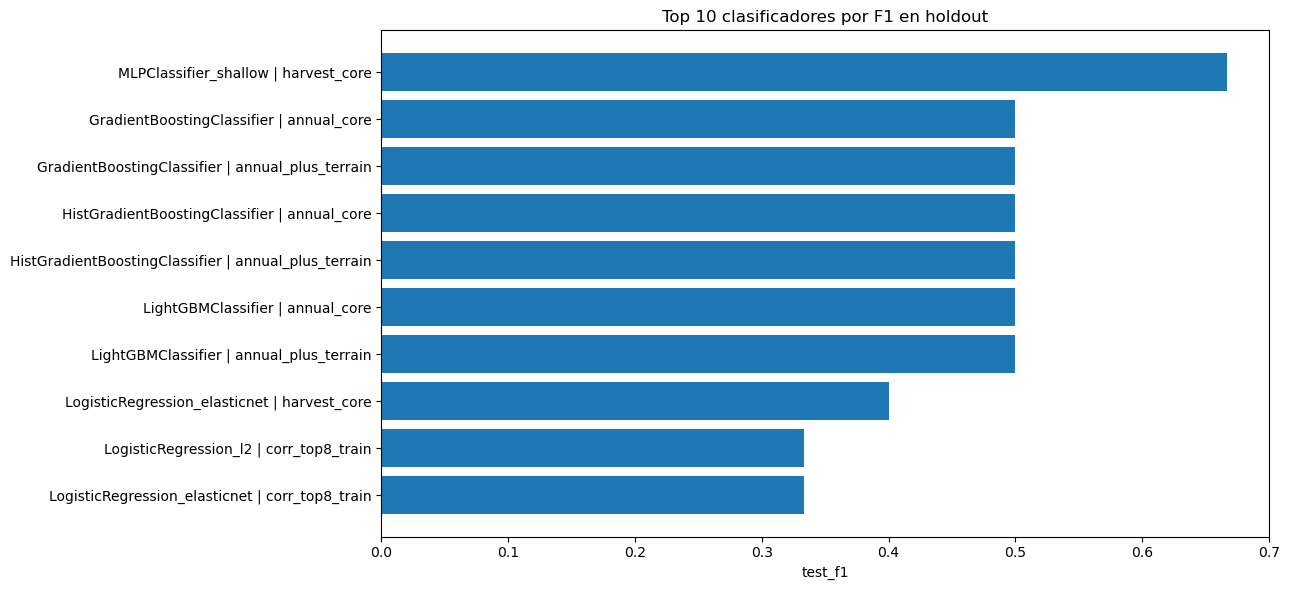

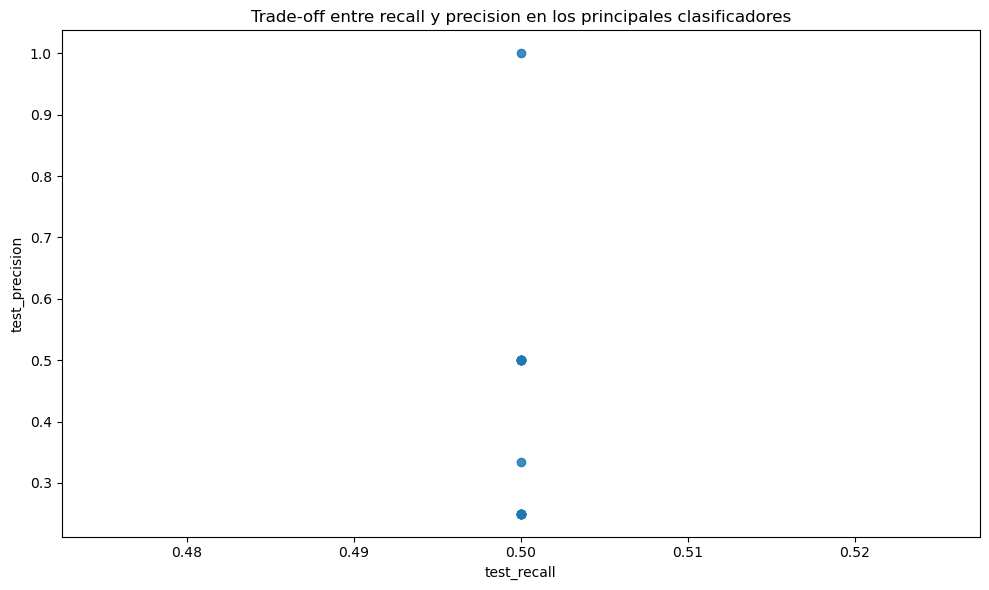

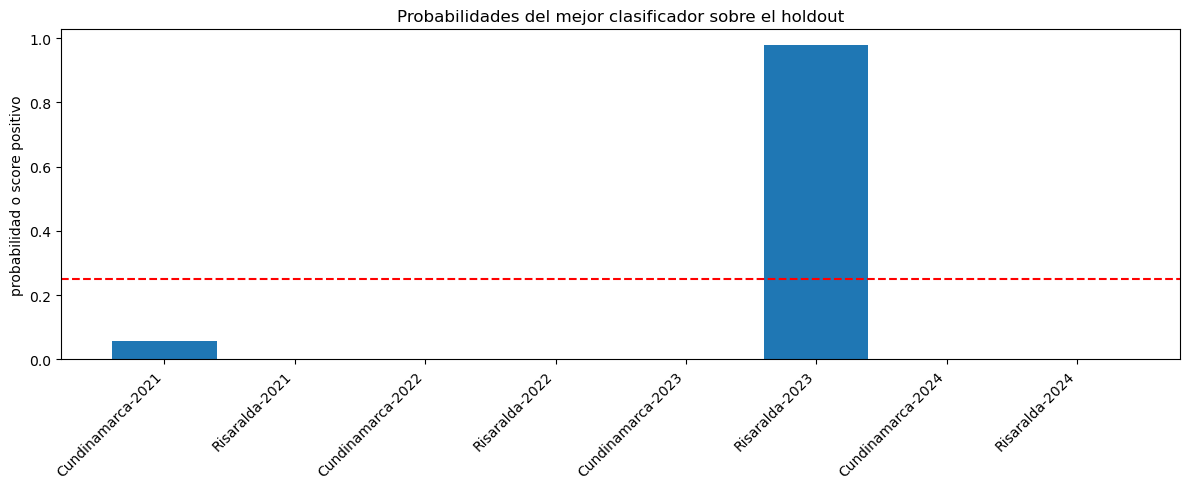

In [52]:
if MATPLOTLIB_AVAILABLE and len(test_results_df) > 0:
    top_plot = top_general_models.head(10).copy()
    labels = top_plot['model_name'] + ' | ' + top_plot['feature_set']
    plt.figure(figsize=(13, 6))
    plt.barh(labels, top_plot['test_f1'])
    plt.gca().invert_yaxis()
    plt.xlabel('test_f1')
    plt.title('Top 10 clasificadores por F1 en holdout')
    plt.tight_layout()
    plt.show()

if MATPLOTLIB_AVAILABLE and len(test_results_df) > 0:
    plot_df = event_priority_models.head(20).copy()
    plt.figure(figsize=(10, 6))
    plt.scatter(plot_df['test_recall'], plot_df['test_precision'], alpha=0.85)
    plt.xlabel('test_recall')
    plt.ylabel('test_precision')
    plt.title('Trade-off entre recall y precision en los principales clasificadores')
    plt.tight_layout()
    plt.show()

if MATPLOTLIB_AVAILABLE and len(top_predictions) > 0:
    best_key = top_models_summary.iloc[0]
    best_pred = top_predictions.loc[
        (top_predictions['model_name'] == best_key['model_name']) &
        (top_predictions['feature_set'] == best_key['feature_set'])
    ].copy()
    best_pred['etiqueta'] = best_pred['departamento'] + '-' + best_pred['anio'].astype(str)
    plt.figure(figsize=(12, 5))
    plt.bar(best_pred['etiqueta'], best_pred['y_score'])
    plt.axhline(float(best_key['threshold_used']), color='red', linestyle='--', linewidth=1.5)
    plt.ylabel('probabilidad o score positivo')
    plt.title('Probabilidades del mejor clasificador sobre el holdout')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## Exportacion de resultados y log de corrida

Se guardan tablas, configuracion y trazas de la corrida para facilitar auditoria, comparacion posterior y uso en el informe tecnico.


In [53]:
export_status = []

try:
    dependency_report.to_csv(OUTPUT_DIR / 'dependencias_detectadas.csv', index=False, encoding='utf-8')
    export_status.append({'archivo': 'dependencias_detectadas.csv', 'estado': 'ok'})
except Exception as exc:
    export_status.append({'archivo': 'dependencias_detectadas.csv', 'estado': f'fallo: {exc}'})

try:
    feature_sets_table.to_csv(OUTPUT_DIR / 'feature_sets_utilizados.csv', index=False, encoding='utf-8')
    export_status.append({'archivo': 'feature_sets_utilizados.csv', 'estado': 'ok'})
except Exception as exc:
    export_status.append({'archivo': 'feature_sets_utilizados.csv', 'estado': f'fallo: {exc}'})

if len(cv_results_df) > 0:
    try:
        cv_results_df.to_csv(OUTPUT_DIR / 'resumen_cv_modelos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_cv_modelos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_cv_modelos.csv', 'estado': f'fallo: {exc}'})

if len(test_results_df) > 0:
    try:
        test_results_df.to_csv(OUTPUT_DIR / 'resumen_test_modelos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_test_modelos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_test_modelos.csv', 'estado': f'fallo: {exc}'})

if len(event_priority_models) > 0:
    try:
        event_priority_models.to_csv(OUTPUT_DIR / 'resumen_test_modelos_priorizando_eventos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_test_modelos_priorizando_eventos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_test_modelos_priorizando_eventos.csv', 'estado': f'fallo: {exc}'})

if len(predictions_df) > 0:
    try:
        predictions_df.to_csv(OUTPUT_DIR / 'predicciones_holdout_todos_los_modelos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'predicciones_holdout_todos_los_modelos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'predicciones_holdout_todos_los_modelos.csv', 'estado': f'fallo: {exc}'})

if len(top_predictions) > 0:
    try:
        top_predictions.to_csv(OUTPUT_DIR / 'predicciones_top_modelos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'predicciones_top_modelos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'predicciones_top_modelos.csv', 'estado': f'fallo: {exc}'})

if len(top_models_summary) > 0:
    try:
        top_models_summary.to_csv(OUTPUT_DIR / 'top_modelos_seleccionados.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'top_modelos_seleccionados.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'top_modelos_seleccionados.csv', 'estado': f'fallo: {exc}'})

if len(candidate_models) > 0:
    try:
        candidate_models.to_csv(OUTPUT_DIR / 'candidatos_modelos_por_objetivo.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'candidatos_modelos_por_objetivo.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'candidatos_modelos_por_objetivo.csv', 'estado': f'fallo: {exc}'})

if len(candidate_summary) > 0:
    try:
        candidate_summary.to_csv(OUTPUT_DIR / 'resumen_candidatos_recomendados.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'resumen_candidatos_recomendados.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'resumen_candidatos_recomendados.csv', 'estado': f'fallo: {exc}'})

if len(adjustments_log) > 0:
    try:
        adjustments_log.to_csv(OUTPUT_DIR / 'ajustes_modelado_clasificacion.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'ajustes_modelado_clasificacion.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'ajustes_modelado_clasificacion.csv', 'estado': f'fallo: {exc}'})

if len(limitations_and_next_steps) > 0:
    try:
        limitations_and_next_steps.to_csv(OUTPUT_DIR / 'limitaciones_y_siguientes_refinamientos.csv', index=False, encoding='utf-8')
        export_status.append({'archivo': 'limitaciones_y_siguientes_refinamientos.csv', 'estado': 'ok'})
    except Exception as exc:
        export_status.append({'archivo': 'limitaciones_y_siguientes_refinamientos.csv', 'estado': f'fallo: {exc}'})

config_payload = {
    'target': TARGET,
    'support_target': SUPPORT_TARGET,
    'train_end_year': TRAIN_END_YEAR,
    'test_start_year': TEST_START_YEAR,
    'small_train_end_year': SMALL_TRAIN_END_YEAR,
    'small_valid_end_year': SMALL_VALID_END_YEAR,
    'cv_min_train_years': CV_MIN_TRAIN_YEARS,
    'cv_valid_window': CV_VALID_WINDOW,
    'thresholds': THRESHOLDS,
    'feature_sets': {k: list(v) for k, v in feature_sets.items()},
    'dependency_status': dependency_status_text(dependency_report),
}
try:
    safe_write_text(OUTPUT_DIR / 'config_experimento.json', json.dumps(config_payload, ensure_ascii=False, indent=2))
    export_status.append({'archivo': 'config_experimento.json', 'estado': 'ok'})
except Exception as exc:
    export_status.append({'archivo': 'config_experimento.json', 'estado': f'fallo: {exc}'})

safe_write_text(OUTPUT_DIR / 'baseline_clasificacion_run_log.txt', '\n'.join(run_log))
export_status.append({'archivo': 'baseline_clasificacion_run_log.txt', 'estado': 'ok o intento de escritura realizado'})

export_status_df = pd.DataFrame(export_status)
display(export_status_df)


,archivo,estado
0,dependencias_detectadas.csv,ok
1,feature_sets_utilizados.csv,ok
2,resumen_cv_modelos.csv,ok
3,resumen_test_modelos.csv,ok
4,resumen_test_modelos_priorizando_eventos.csv,ok
5,predicciones_holdout_todos_los_modelos.csv,ok
6,predicciones_top_modelos.csv,ok
7,top_modelos_seleccionados.csv,ok
8,candidatos_modelos_por_objetivo.csv,ok
9,resumen_candidatos_recomendados.csv,ok


## Lectura final del bloque de clasificacion

El valor de este cuaderno no esta solo en encontrar un clasificador ganador. Tambien deja trazable como cambian las conclusiones cuando se privilegia desempeno general o sensibilidad a eventos, y prepara la articulacion con la capa operacional mensual de clasificacion.


In [54]:
final_summary = []

if len(test_results_df) > 0:
    best_general = top_general_models.iloc[0]
    best_event = event_priority_models.iloc[0] if len(event_priority_models) > 0 else best_general
    final_summary.extend([
        {'tema': 'mejor_clasificador_general', 'lectura': f"{best_general['model_name']} con feature_set {best_general['feature_set']}"},
        {'tema': 'mejor_f1_holdout', 'lectura': f"{best_general['test_f1']:.4f}"},
        {'tema': 'mejor_balanced_accuracy_holdout', 'lectura': f"{best_general['test_balanced_accuracy']:.4f}"},
        {'tema': 'umbral_mejor_modelo_general', 'lectura': f"{best_general['threshold_used']:.2f}"},
        {'tema': 'mejor_clasificador_eventos', 'lectura': f"{best_event['model_name']} con feature_set {best_event['feature_set']}"},
        {'tema': 'recall_mejor_modelo_eventos', 'lectura': f"{best_event['test_recall']:.4f}"},
        {'tema': 'f1_mejor_modelo_eventos', 'lectura': f"{best_event['test_f1']:.4f}"},
        {'tema': 'necesidad_de_capa_operacional_clasificacion', 'lectura': 'si, para traducir estos hallazgos a alertas mensuales y trigger'},
    ])
else:
    final_summary.append({'tema': 'estado', 'lectura': 'No se ejecutaron clasificadores en este entorno porque faltan dependencias o hubo restricciones en la corrida.'})

display(pd.DataFrame(final_summary))
print('Notebook 11 listo.')


,tema,lectura
0,mejor_clasificador_general,MLPClassifier_shallow con feature_set harvest_core
1,mejor_f1_holdout,0.6667
2,mejor_balanced_accuracy_holdout,0.7500
3,umbral_mejor_modelo_general,0.25
4,mejor_clasificador_eventos,MLPClassifier_shallow con feature_set harvest_core
5,recall_mejor_modelo_eventos,0.5000
6,f1_mejor_modelo_eventos,0.6667
7,necesidad_de_capa_operacional_clasificacion,"si, para traducir estos hallazgos a alertas mensuales y trigger"


Notebook 11 listo.
